In [2]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

In [3]:
customer_data = pd.read_csv('csv_data/olist_customers_dataset.csv')
orders_data = pd.read_csv('csv_data/olist_orders_dataset.csv', parse_dates=['order_delivered_customer_date', 'order_estimated_delivery_date', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date'])
order_items_data = pd.read_csv('csv_data/olist_order_items_dataset.csv', parse_dates=['shipping_limit_date'])

In [37]:
#проверим данные на наличие пустых значений
print("Быстрый взгляд на талицу пользователей")
print(customer_data.isna().sum())
print(customer_data.dtypes)
print(customer_data.head())

Быстрый взгляд на талицу пользователей
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao b

In [38]:
print("Быстрый взгляд на талицу заказов")
print(orders_data.isna().sum())
print(orders_data.dtypes)
print(orders_data.head())

Быстрый взгляд на талицу заказов
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec6

In [39]:
print("Быстрый взгляд на талицу товаров")
print(order_items_data.isna().sum())
print(order_items_data.dtypes)
print(order_items_data.head())

Быстрый взгляд на талицу товаров
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca9

На данном этапе все в  порядке, когортный анализ мы будем строить относительно order_purchase_timestamp. 

Сперва необходимо оценить месячный retention в оформление заказа с помощью когортного анализа, так как важно, чтобы клиенты возвращались в маркетплейс для совершения больших покупок.

In [6]:
#так как нужно найти возвращаемость клиента в оформление заказа, то делаем объединение таблиц
df = orders_data.merge(customer_data[['customer_id', 'customer_unique_id']], on='customer_id')
data_copy = df.copy() 
# скопировали ДФ для дальнейших манипуляций в следующих заданиях

In [7]:
#нам нужны неотмененные заказы, то есть 100% подтверженные 
confirmed_orders = df.dropna(subset=['order_approved_at'])
# дополнительно убеждаемся, что статус не "отменен"
confirmed_orders = confirmed_orders.query("order_status not in ['canceled', 'unavailable']")

In [8]:
# месяц конкретного заказа
confirmed_orders['order_month'] = confirmed_orders['order_purchase_timestamp'].dt.to_period('M')
# месяц самой первой покупки для каждого пользователя
confirmed_orders['cohort'] = confirmed_orders.groupby('customer_unique_id')['order_month'].transform('min')

In [9]:
#смотрим через сколько месяцев был сделал текущий заказ относительно первого, это будет "индексом" когорты
confirmed_orders['cohort_index'] =(confirmed_orders['order_month'] - confirmed_orders['cohort']).apply(lambda x: x.n)


In [10]:
#мы группируем данные по месяцу рождения когорты и номеру месяца жизни
# считаем именно уникальных пользователей
cohort_data = confirmed_orders.groupby(['cohort', 'cohort_index'])['customer_unique_id'].nunique().reset_index()

In [11]:
#разворачиваем таблиц для дальнейшей более удобной работы и визуаизации
retention_matrix = cohort_data.pivot(index='cohort', columns='cohort_index', values='customer_unique_id')

In [12]:
#расчитываем размер когорт и коэфициенты удержания
cohort_sizes = retention_matrix.iloc[:, 0]
retention_matrix = retention_matrix.divide(cohort_sizes, axis=0)


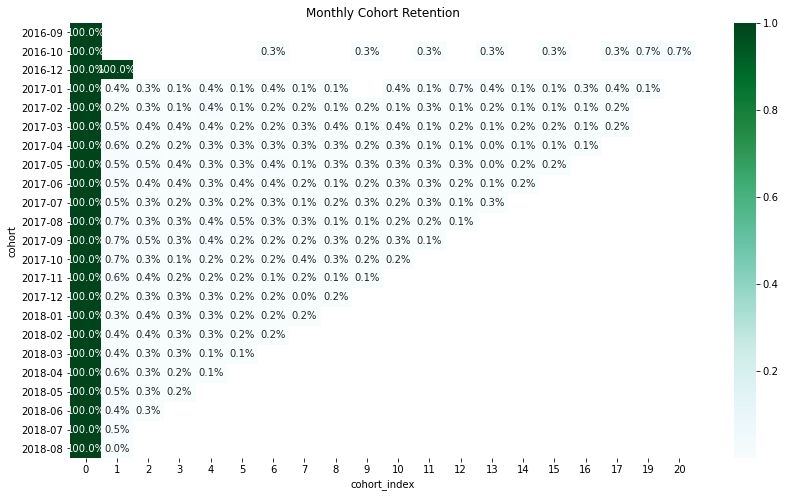

In [13]:
plt.figure(figsize=(14, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.1%', cmap='BuGn')
plt.title('Monthly Cohort Retention')
plt.show()

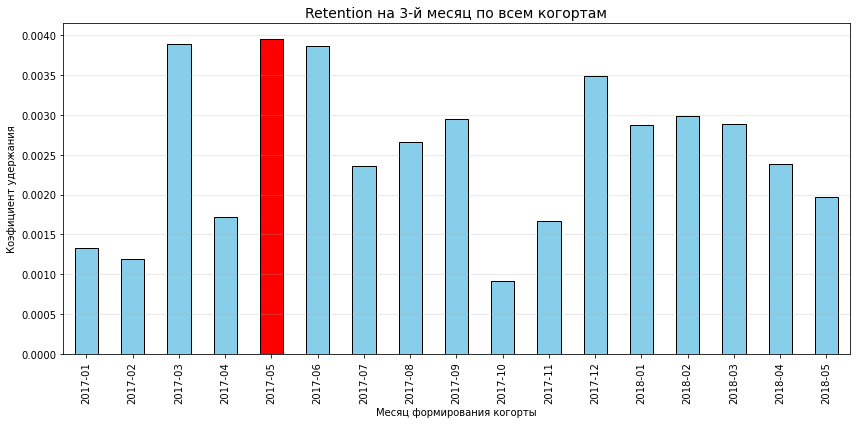

Медианный retention 1-го месяца =  0.5 %
Максимальный retention 3-го месяца =  0.4 %


In [14]:
#находим медианный ретеншн за 1 месяц и самый высокий ретеншн за третий месяц жизни, выделяем когорту с самым высоким показателем на графике
retention_3rd_month = retention_matrix[1].dropna()
median_val = retention_3rd_month.median() 

retention_3rd_month = retention_matrix[3].dropna()


plt.figure(figsize=(12, 6))
retention_3rd_month.plot(kind='bar', color='skyblue', edgecolor='black')


max_val = retention_3rd_month.max()
max_idx = retention_3rd_month.argmax()
plt.gca().patches[max_idx].set_facecolor('red')

plt.title('Retention на 3-й месяц по всем когортам', fontsize=14)
plt.ylabel('Коэфициент удержания')
plt.xlabel('Месяц формирования когорты')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Медианный retention 1-го месяца = ", round(median_val, 3)*100, "%")
print("Максимальный retention 3-го месяца = ", round(max_val, 3)*100, "%")

# Вывод 
мы наблюдаем критически низкий возврат к нашему продукту. Если взять медианный retention первого месяца, то это всего 0.5% то есть с 1000 новых клиентов к нам вернутся всего лишь 5 человек. так маркетплейс скорее используется как место единоразовой покупки, а не как любимый маркетплейс.

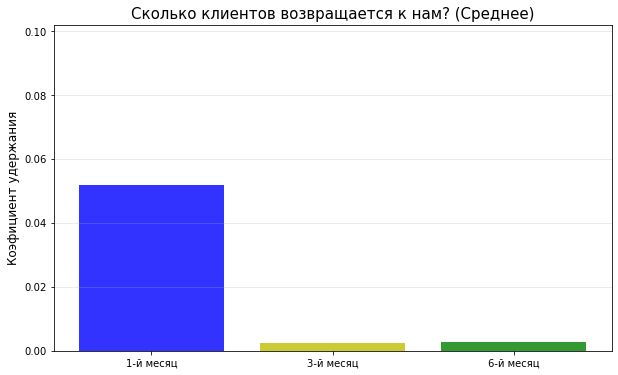

In [40]:
# еще более ясно проиллюстрируем возвращаемость клиентов, используя 1, 3, 6 месяцы после первой покупки.
milestones = [1, 3, 6]
values = [retention_matrix[m].mean() for m in milestones]
labels = [f'{m}-й месяц' for m in milestones]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=['b', 'y', 'g'], alpha=0.8)


plt.title('Сколько клиентов возвращается к нам? (Среднее)', fontsize=15)
plt.ylabel('Коэфициент удержания', fontsize=12)
plt.ylim(0, max(values) + 0.05) 
plt.grid(axis='y', alpha=0.3)

plt.show()
# как видим, клиентов мы теряем стремительно и практически полностью.

Построив retention, вы решили оценить, насколько хорошо продукт закрывает потребности клиента.
А именно, существует ли product/market fit у маркетплейса.

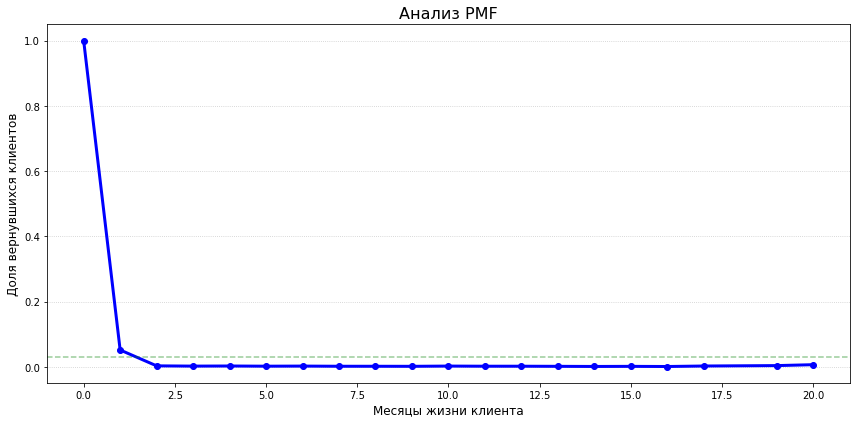

In [17]:
# так как данных маркетинговых расходов нам не известны, сделаем простую визуализацию (кривую удержания)
mean_retention = retention_matrix.mean().dropna()

plt.figure(figsize=(12, 6))

plt.plot(mean_retention.index, mean_retention.values, marker='o', linestyle='-', linewidth=3, color='b')
# делаем примерную границу удовлетворительной конверсии (2 -3 %)
plt.axhline(y=0.03, color='green', linestyle='--', alpha=0.4)


plt.title('Анализ PMF', fontsize=16)
plt.xlabel('Месяцы жизни клиента', fontsize=12)
plt.ylabel('Доля вернувшихся клиентов', fontsize=12)

plt.grid(True, axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

В целом, даже без вычислений метрик типа LTV, CAC (недостаточно данных), можно сказать, что PMF нет, так как кривая не фиксируется на должно уровне выше 0, а сразу падает, достигая к 6-му месяцу значения менее 0.2%.
Получается, что выручка компании состоит только из новых клиентов, которые совершают покупку единоразово и позже не возвращаются
 
Предполагаемые причины: 
1. Специфичный товар (декор, электроника или экзотика), тогда клиенту попросту незачем возвращаться за повторной покупкой, она не повседневная
2. Это вполне может быть проблема с долгой доставкой, особенно при высокой цене. Люди не готовы слишком долго ждать или доставка регулярно задерживается
3. Баг в системе на определенном этапе.
Посмотрим на датасет подробнее

In [41]:
# Разберем проблемы с доставкой

data_copy['delivery_delta'] = (data_copy['order_delivered_customer_date'] - 
                               data_copy['order_estimated_delivery_date']).dt.days

data_copy['is_late'] = data_copy['delivery_delta'] > 0
data_copy_for_stat = data_copy.dropna().copy()
# посмотрим небольшую табличку и посмотрим коэфициент следующей покупки
late_retention = data_copy_for_stat.groupby('is_late')['customer_unique_id'].apply(
    lambda x: data_copy_for_stat[data_copy_for_stat['customer_unique_id'].isin(x)].groupby('customer_unique_id')['order_id'].count().mean() - 1
).reset_index()

print("Влияют ли задержки по доставке на желание совершить следующу покупку?\n", late_retention)
# кажется, что мы не правы(, но над логистикой я бы тоже поработала, конечно. Т.е. у нас получилось, что люди, у которых не было проблем с доставкой
# возращаются меньше. Что вызывает еще больше вопросов, которые мы посмотрим далее.

Влияют ли задержки по доставке на желание совершить следующу покупку?
    is_late  customer_unique_id
0    False            0.035447
1     True            0.054478


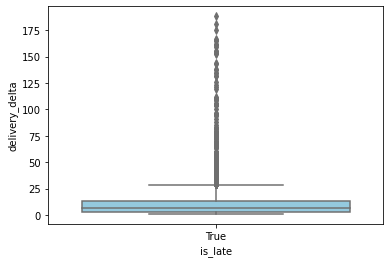

In [20]:
sns.boxplot(x='is_late', y='delivery_delta', data=data_copy.query('is_late == True'), color ='skyblue')
# Если посмотреть на boxplot то становится ясно, что задержки есть, да еще и немалые! Более того, медианная задержка доставки
# составила целых 7 дней, не говоря о том, что есть значительные выбросы (более 175 дней задержки).

In [21]:
median_delivery_late = data_copy[data_copy.is_late == True].delivery_delta.median()
print("Медианная задержка при доставке товаров = ", median_delivery_late, "дней")

Медианная задержка при доставке товаров =  7.0 дней


In [22]:
# проверим еще момент на некий баг в нашей системе, подозрительно, что approved_at не появляется в строках (есть NaN)
active_orders_bags = data_copy.query("order_status not in ['canceled', 'unavailable']").copy().dropna(subset=['order_delivered_carrier_date', 'order_approved_at'])

active_orders_bags['processing_time'] = (
    active_orders_bags['order_delivered_carrier_date'] - active_orders_bags['order_approved_at']
).dt.total_seconds() / 3600

long_time_10 = active_orders_bags['processing_time'] > 10
long_time_10 = long_time_10.sum() 
long_time_48 = active_orders_bags['processing_time'] > 48
long_time_48 = long_time_48.sum() 

print("Число заказов, которые подтвержали больше 10-ти часов = ", long_time_10)
print("Число заказов, которые подтвержали больше 48-ми часов = ", long_time_48)
print("Общее число подтвержденных заказов = ", len(active_orders_bags))
# почти все заказы подтвержали с огромной задержкой

Число заказов, которые подтвержали больше 10-ти часов =  88910
Число заказов, которые подтвержали больше 48-ми часов =  45047
Общее число подтвержденных заказов =  97569


То есть почти все заказы не подтверждаются вовремя!

In [23]:
canceled_orders = data_copy.query("order_status == 'canceled'").copy()
# если order_approved_at пустой (NaN) у большинства отмен — баг 
no_approval_canceled =  canceled_orders['order_approved_at'].isna().sum()
error = active_orders_bags['order_delivered_customer_date'] < active_orders_bags['order_delivered_carrier_date']

 
print("число заказов отменнных до подтвержения оплаты = ", no_approval_canceled)
print("дата доставки раньше, чем дата передачи логистам = ", error.sum())
print("всего отмененных заказов = ", len(canceled_orders))
# уже явно видно, что наша система имеет какую-то ошибку/неточности



число заказов отменнных до подтвержения оплаты =  141
дата доставки раньше, чем дата передачи логистам =  23
всего отмененных заказов =  625


In [24]:
# далее рассмотрим разрез по количеству товара на пользователя (так как категории или названиями не располагаем)
#  если человек покупает 1 товар в cреднем, то это что-то не повседневное, нужно менять ассортимент 
df_items = data_copy.merge(order_items_data, on='order_id').copy()

In [25]:
top_products_repeat = df_items.groupby('product_id').agg({'customer_unique_id': 'nunique', 'order_id': 'count'})

top_products_repeat['orders_per_user'] = top_products_repeat['order_id'] / top_products_repeat['customer_unique_id']

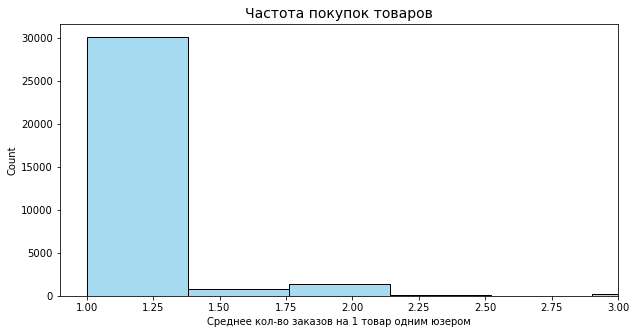

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(top_products_repeat['orders_per_user'], bins=50, color='skyblue')

plt.title('Частота покупок товаров', fontsize=14)
plt.xlabel('Среднее кол-во заказов на 1 товар одним юзером')
plt.xlim(0.9, 3) 
plt.show()

# Здесь уже вырисовывается реальная проблема, товары и правда не каждутся подходящими для повседневной покупки, вот люди и не остаются

## Подбор метрик

### 5 основных метрик, которые можно начать отслеживать в этом бизнесе, для улучшения его состояния

#### *1. Выручка (объем продаж)*

Метрика для отслеживания в динамике. Будет видно, насколько растет наша выручка с каждыйм месяцем/кварталом и т.д. Можно от визуализировать прирост в процентном соотношении для удобства. 

#### *2. MAU*

Метрика показывает количество активных пользователей за месяц, если эта метрика растет, а выручка нет, то мы привлекааем одноразовых клиентов. Если наоборот, растет выручка, а количество пользователей стоит на месте - значит, наши пользователи стали больше покупать, но новых пользователей мы не привлекаем. В идеале должны расти обе метрики. 

#### *3. CAC*

Метрика показывает сколько стоит привлечь клиента в наш продукт, если САС растет, значит, как бренд мы исчезаем, а привлекать людей становится все сложнее и сложнее.. 

#### *4.  Retention*

Наша главная «боль». Эта метрика показывает процент клиентов, вернувшихся за второй покупкой. Как мы выяснили, с этой метрикой точно нужно работать! Рост этой метрики — единственный способ сдвинуть выручку с мертвой точки без бесконечного раздувания рекламного бюджета.

#### *5.  LTV*

Метрика о том, сколько денег мы получим с клиента за все его врем жизни на маркетплейсе. Если метрика равна сумме первого заказа, то вовлеченность явно отсутствует. 

Дальше представим визуализации некоторых метрик для задания номер 4! 

In [27]:
# считаем метрики и визуализируем, но для начала, готовим датасет
data_copy_full = data_copy.merge(order_items_data, on = 'order_id')
active_orders = data_copy_full.query("order_status not in ['canceled', 'unavailable']").copy()
active_orders['month'] = active_orders['order_purchase_timestamp'].dt.to_period('M')

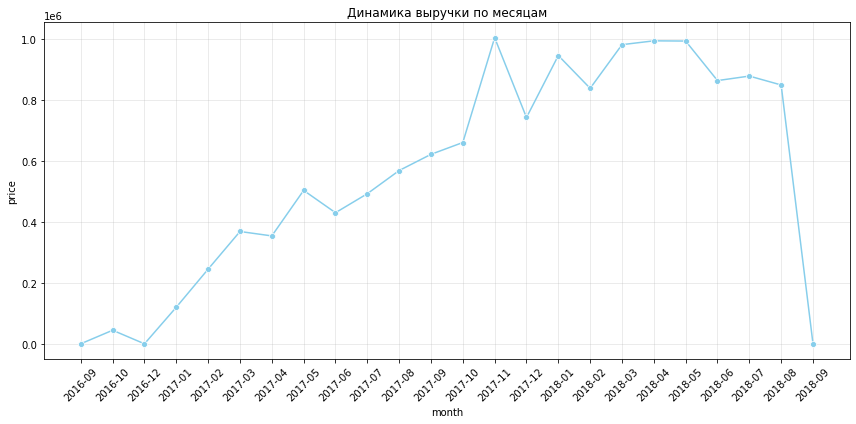

In [28]:
# 1 метрика - выручка
revenue = active_orders.groupby('month')['price'].sum().reset_index()


plt.figure(figsize=(12, 6))
sns.lineplot(data=revenue, x=revenue['month'].astype(str), y='price', marker='o', color = 'skyblue')
plt.title('Динамика выручки по месяцам')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# выручка с течением времени увеличивается, но, если посмотреть на суммы, все еще маленькая относительно маркетплейса
# также стоит выделить очевидное ее падение спустя время, что говорит о падении спроса и активности пользователей
# мысленно не берем последний месяц, там всего 1 подходящий пользователь (недостаточно данных)


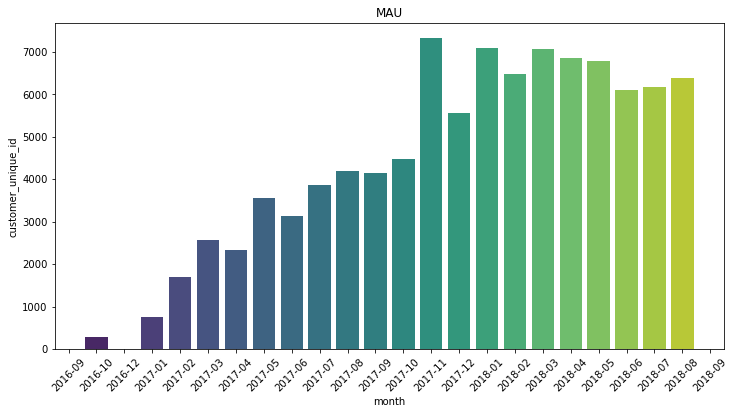

In [29]:
# 2 метрика - MAU 
# считаем как количество уникальный пользователей за месяц
# в целом, можно использовать и линейный график, barplot взят ради разнообразия
mau = active_orders.groupby('month')['customer_unique_id'].nunique().reset_index()


plt.figure(figsize=(12, 6))
sns.barplot(data=mau, x=mau['month'].astype(str), y='customer_unique_id', palette='viridis')
plt.title('MAU')
plt.xticks(rotation=45)
plt.show()

# метрика постепенно увеличивается с течением времени и более-менее фиксируется через некоторое время
# т.е. потом новых пользователей у нас, как минимум, есть!

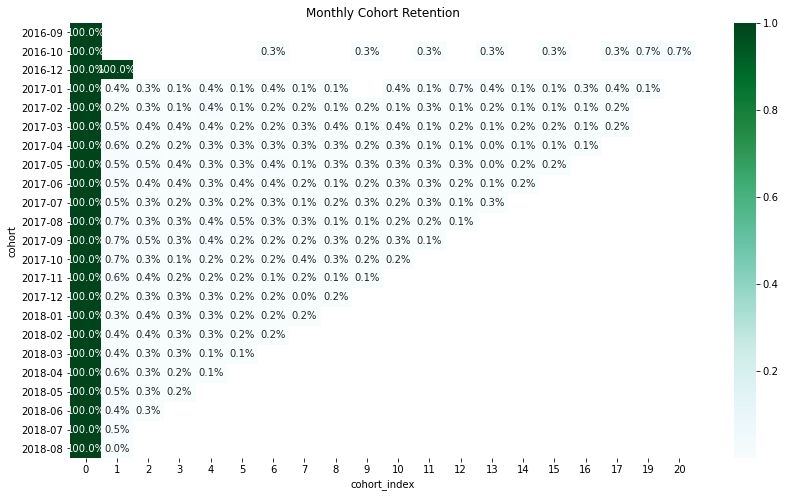

In [30]:
# повторно визуализируем метрику 3 - retention
active_orders['first_month'] = active_orders.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')

active_orders['order_month'] = active_orders['order_purchase_timestamp'].dt.to_period('M')
active_orders['cohort'] = active_orders.groupby('customer_unique_id')['order_month'].transform('min')
active_orders['cohort_index'] =(active_orders['order_month'] - active_orders['cohort']).apply(lambda x: x.n)
cohort_data1 = active_orders.groupby(['cohort', 'cohort_index'])['customer_unique_id'].nunique().reset_index()
retention_matrix1 = cohort_data.pivot(index='cohort', columns='cohort_index', values='customer_unique_id')

cohort_size1 = retention_matrix1.iloc[:, 0]
retention_matrix1 = retention_matrix1.divide(cohort_size1, axis=0)

plt.figure(figsize=(14, 8))
sns.heatmap(retention_matrix1, annot=True, fmt='.1%', cmap='BuGn')
plt.title('Monthly Cohort Retention')
plt.show()

# на этом этапе решила еще пояснить, что для когорт был выбран не 'кастомный' месяц, а календарный 
# т.к. нашла пару примеров из бизнеса и пару советов о том, что настоящие кейсы расчитывают на календарном месяце, подумала, что это логично 
# также отмечу, что для достоверности я пересчитала и с 'кастомным' месяцем, получилась погрешность в +-0.1, что в целом некритично в нашем случае
# Также далеко не все значения различались, так что я оставила именно этот вариант. Спасибо за внимание


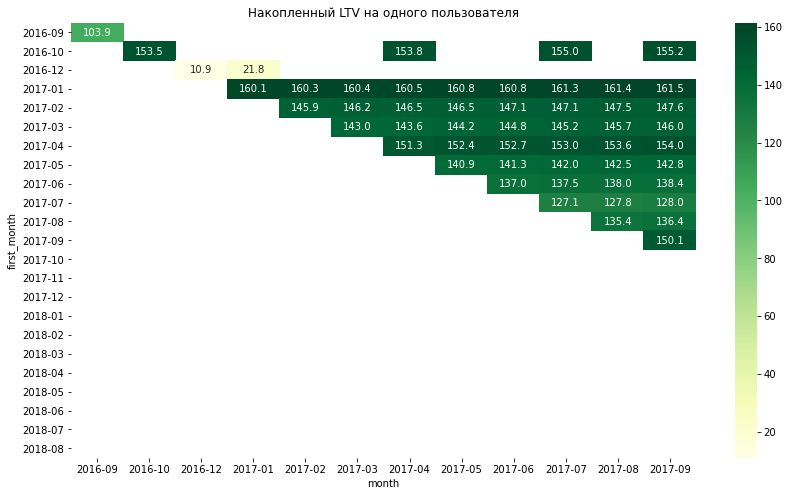

In [31]:
# последняя метрика для визуализации - LTV 
# я прочитала, что удобный способ визуализации - это тепловая карта, как в retention
# чтобы цифры были лучше видны, ограничим диапазон 12-ю месяцами
# расчитываем как накопленную сумму когорты /количетво людей в этой когорте 
ltv = active_orders.groupby(['first_month', 'month'])['price'].sum().reset_index()
ltv['cumulative_revenue'] = ltv.groupby('first_month')['price'].cumsum()
ltv_pivot = ltv.pivot_table(index='first_month', columns='month', values='cumulative_revenue')
ltv_per_user = ltv_pivot.divide(cohort_size1, axis=0)

plt.figure(figsize=(14, 8))
sns.heatmap(ltv_per_user.iloc[:, :12], annot=True, fmt='.1f', cmap='YlGn')
plt.title('Накопленный LTV на одного пользователя')
plt.show()

# относительно реальных маркетплейсов сумма небольшая
# причины:
# -очень маленькая возвращаемость в продукт
# -средний чек, которые равен одному продукту (чаще покупат только 1 товар, исходя из анализа выше)

Посмотрев с продактом на когортный анализ и метрики, вы решили, что нужно изменить продукт. Метрики необходимо срочно повышать. Вместе с командой были сформулированы 3 гипотезы, в которые вы верите. По каждой гипотезе команда заполнила показатели по Ease, Confidence. 

Для расчёта Impact возьмем данные с июня 2017 года. Будем считать, что конверсия в повторный заказ равна величине медианного retention 1-го месяца

In [33]:
data_since_june = data_copy.query("order_purchase_timestamp >= '2017-06-01'").copy()

# (Гипотеза 1) снижения количества отмен
# Считаем все заказы со статусом 'canceled', а с принятием гипотезы, мы избавимся от всех отмен
lost_orders_canceled = data_since_june.query("order_status == 'canceled'")['order_id'].nunique()

# количество повторных заказов (Гипотезы 2 и 3)
# по условию: Конверсия = Медианный Retention 1-го месяца
# мы смотрим один и тот же показатель (прирост повторных заказов) с теми же входными данными, поэтому Impact будет 1 на двоих

# считаем количество уникальных клиентов с июня 2017
unique_customers_since_june = data_since_june['customer_unique_id'].nunique()
# потенциальные повторные заказы
potential_repeat_orders = unique_customers_since_june * median_val

print("Гипотеза 1 - ", lost_orders_canceled, " Impact = 4")
print("Гипотезы 2, 3 - ", round(potential_repeat_orders), " Impact = 4")

Гипотеза 1 -  499  Impact = 4
Гипотезы 2, 3 -  430  Impact = 4


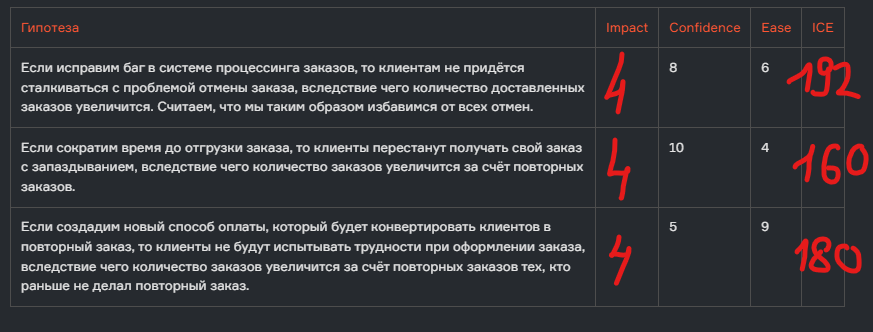



*Очевидно, что выбрали мы гипотезу номер 1, т.к. скор по шкале был выше всего*

### На какие метрики повлияет внедрение нашей гипотезы? 

*Первое - **выручка**. Баг исправлен, а следовательно клиенты смогут оформлять заказы без проблем, покупая больше. 
Второе - **количество отмен**. Так как отмены были багом нашей системы, то их количество снизится
**LTV** - по той же логике, покупать будут больше, принесут за свой жизнейнный цикл больше!* 

Это то, что очевидно увеличится почти сразу, так как есть приток новых пользователей. А остальное, например, retention настолько спрогнозировать не получится, так как не только баг, но и ассортимент мог влиять на уход пользователей. 

##### Для гипотезы об исправлении бага в системе процессинга заказов метрики должны отражать путь заказа от создания до успешного получения денег.

###  Целевая метрика (главная мерика)
*Доля успешно доставленных заказов* -  если баг в процессинге исправлен, заказы перестанут «отваливаться» на этапе обработки и будут доходить до клиента, также отражение этой метрики можно будет заметить на выручке. 

### Прокси-метрика (связанная с целевой) 
*Коэффициент отмен* -  быстрее реагирует на изменения, не нужно ждать, пока заказ доедет до клиента (как в случае с доставкой), чтобы увидеть результат. Сразу увидим снижение это метрики на этапе подтверждения 

### Барьерная метрика (сигнал о проблемах в процессе эксперимента)
*Среднее время подтверждения заказа* - если мы добавим лишние проверки или как-то нагрузим систему слишком сильно, то подтвержение заказа может стать слишком медленным. И мы, как следствие, ухудшим пользовательский опыт на нашем маркеплейсе

##  ФИНАЛЬНЫЙ ОТЧЕТ РУКОВОДИТЕЛЮ

В ходе анализа данных маркетплейса по продаже бразильских товаров выявлена критическая проблема: **крайне низкий уровень удержания клиентов (Retention).**
При проведении базовых манипуляций и, вследствии, проведенного когортного анализа, было выяснено, что медианный retention первого месяца стремится к 0. Более того, большинство пользователей совершают только 1 покупку, после чего не возвращаются. 

Нашу текущую выручку обеспечивает только приток новых пользователей, из чего следует, что на привлечение мы тратим большие деньги, тогда как "старые" пользователи не приносят повторной прибыли. 


### Исследование проблемы 

Изучив несколько основных метрик (выручка, MAU, LTV, retention), мы можем сделать пару выводов о текущем состоянии бизнеса Пети и выделить ряд ключевых проблем:<br>

--- существует прямая зависимость выручки от количества активных пользователей. Поскольку возвращаемость низкая, бизнес полностью зависит от объемов маркетингового бюджета на привлечение;<br>
--- накопленный доход на одного пользователя (LTV) почти не растет во время использования нашег маркетплейса. Это подтверждает отсутствие привычки повторного потребления на платформе;<br>
--- также, стоит упомянуть и проверку на баги системы. Очевидно, что заказ не может быть отменен пользователем до оплаты. или, если  дата доставки меньше даты передачи в доставку - это тоже ошибка. Эти баги мы нашли у себя в данных, значит, это тоже считаем нашей проблемой; <br>
--- доставка задерживаеся на продолжительное время (все-таки Бразилия далеко), так, медианное количество дней задержки - 7, имеются и аномально высокие значения задержек (до 188 дней). 


### Рекомендации по продукту

#### Главный фокус:  
--- убрать неполадки в системе процессинга заказов. Так мы сразу повлияем на долю отмененных заказов и повысим лояльность клиентов; <br>
--- удержание клиентов с нами: стимулировать переход ко второму заказу у клиентов, путям создания push-уведомлений, email зассылок и/или добавления повседневных товаров на маркетплейс (если они отсутствуют); <br>
--- следить за временем подтверждения заказа. Любые правки не должны замедлять путь клиента от корзины до оплаты и ухудшать пользовательский опыт.


#### Прочее:

--- несмотря на то что пользователи проявляют лояльность к долгим срокам ожидания товара, текущие аномальные задержки (полгода) недопустимы в долгосрочной перспективе. По меркам конкурентов и человеческого отношения, нужно или улучшать систему прогнозирования доставки, или внедрять бонусы для тех, кто ждал свой товар с критической задержкой, или менять логистическу компанию, сокращая сам срок доставки.

